# After Cleaning Analysis

This notebook uses `MoreStrictDataCleaner` to clean the CMsiRNAdb dataset and then analyzes the cleaned dataframe.

In [1]:
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.data_cleaning_more_strict import MoreStrictDataCleaner
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## Load And Clean The Dataset

In [2]:
raw_data_path_env = os.environ.get("CMSIRNA_RAW_DATA_PATH")
processed_dir_env = os.environ.get("CMSIRNA_PROCESSED_DIR")

if not raw_data_path_env:
    raise ValueError("Set CMSIRNA_RAW_DATA_PATH in your local .envrc before running this notebook.")
if not processed_dir_env:
    raise ValueError("Set CMSIRNA_PROCESSED_DIR in your local .envrc before running this notebook.")

data_path = Path(raw_data_path_env).expanduser()
processed_dir = Path(processed_dir_env).expanduser()

df_raw = pd.read_csv(data_path, sep="\t", low_memory=False)
cleaner = MoreStrictDataCleaner(df_raw.copy())
df_clean = cleaner.clean().copy()

print("Raw shape:", df_raw.shape)
print("Cleaned shape:", df_clean.shape)
display(df_clean.head())

dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Raw shape: (43153, 26)
Cleaned shape: (33450, 20)


/Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/utils/data_cleaning_more_strict.py:48: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.file["Time_of_administration"] = parsed.where(parsed.notna(), self.file["Time_of_administration"])


,ID,patent_ID,Authorization_status,Accession_number,Target_Gene,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,Modification_Types_Antisense_strand,Sense_seqence,length_sense_strand,Modification_Types_Sense_strand,Inhibition,SD,Cell_Type,Concentration,Time_of_administration,Title
0,001-01-01-00001-100n-48h-88.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D1,UUAGAAAGCUGAUGGACCAUAACUG,25.0,UUAGAAAGCUGAUGGACCAUAACUG,1*U || 2*U || 3*A || 4*G || 5*A || 6*A || 7*A ...,CAGUUAUGGUCCAUCAGCUUUCUAA,25.0,1*2'-O-Methylcytidine || 2*2'-O-Methyladenosin...,88.0,NaN,Hela,100.0,48,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物
1,001-01-01-00002-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D2,UACAAUAGCAGACACCAUCUGAGGA,25.0,UACAAUAGCAGACACCAUCUGAGGA,1*U || 2*A || 3*C || 4*A || 5*A || 6*U || 7*A ...,UCCUCAGAUGGUGUCUGCUAUUGUA,25.0,1*2'-O-Methyluridine || 2*2'-O-Methylcytidine ...,90.0,NaN,Hela,100.0,48,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物
2,001-01-01-00003-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D3,UGAACAAGACGUUGACUUGGAUCUG,25.0,UGAACAAGACGUUGACUUGGAUCUG,1*U || 2*G || 3*A || 4*A || 5*C || 6*A || 7*A ...,CAGAUCCAAGUCAACGUCUUGUUCA,25.0,1*2'-O-Methylcytidine || 2*2'-O-Methyladenosin...,90.0,NaN,Hela,100.0,48,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物
3,001-01-01-00004-100n-48h-89.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D4,UUUAGUUGCAGCAUCUGAAAGAUUC,25.0,UUUAGUUGCAGCAUCUGAAAGAUUC,1*U || 2*U || 3*U || 4*A || 5*G || 6*U || 7*U ...,GAAUCUUUCAGAUGCUGCAACUAAA,25.0,1*2'-O-Methylguanosine || 2*2'-O-Methyladenosi...,89.0,NaN,Hela,100.0,48,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物
4,001-01-01-00005-100n-48h-87.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D5,UUUCGAAUCAAUCCAACAGUAGCCU,25.0,UUUCGAAUCAAUCCAACAGUAGCCU,1*U || 2*U || 3*U || 4*C || 5*G || 6*A || 7*A ...,AGGCUACUGUUGGAUUGAUUCGAAA,25.0,1*2'-O-Methyladenosine || 2*2'-O-Methylguanosi...,87.0,NaN,Hela,100.0,48,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物


## Analysis Helpers

In [3]:
def summarize_numeric(series, label):
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    return pd.DataFrame({
        "metric": [f"{label}_min", f"{label}_max", f"{label}_avg"],
        "value": [numeric.min() if len(numeric) else np.nan, numeric.max() if len(numeric) else np.nan, numeric.mean() if len(numeric) else np.nan],
    })

def invalid_characters(series):
    chars = []
    for value in series.dropna():
        seq = re.sub(r"\s", "", str(value))
        chars.extend([char for char in seq if char.upper() not in {"A", "C", "G", "U", "T"}])
    if not chars:
        return pd.DataFrame(columns=["invalid_character", "count"])
    return pd.Series(chars, name="invalid_character").value_counts().rename_axis("invalid_character").reset_index(name="count")

def invalid_sequences(series):
    cleaned = series.dropna().astype(str).str.replace(r"\s", "", regex=True)
    invalid_mask = ~cleaned.str.fullmatch(r"[ACGUTacgut]+", na=False)
    invalid_only = cleaned[invalid_mask]
    if invalid_only.empty:
        return pd.DataFrame(columns=["sequence", "count"])
    return invalid_only.value_counts().rename_axis("sequence").reset_index(name="count")

In [4]:
df_analysis = df_clean.copy()

df_analysis["sense_length_calculated"] = df_analysis["Sense_seqence"].fillna("").str.replace(r"\s", "", regex=True).str.len()
df_analysis["antisense_length_calculated"] = df_analysis["Antisense_seqence"].fillna("").str.replace(r"\s", "", regex=True).str.len()

df_analysis["sense_length_inconsistent"] = df_analysis["length_sense_strand"].notna() & (df_analysis["sense_length_calculated"] != pd.to_numeric(df_analysis["length_sense_strand"], errors="coerce"))
df_analysis["antisense_length_inconsistent"] = df_analysis["length_anti_sense_strand"].notna() & (df_analysis["antisense_length_calculated"] != pd.to_numeric(df_analysis["length_anti_sense_strand"], errors="coerce"))

## 1. Missing Values Per Column

In [5]:
missing_count = df_analysis.isna().sum().sort_values(ascending=False)
missing_percent = (missing_count / len(df_analysis) * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent,
})
display(missing_summary)

,missing_count,missing_percent
SD,19118,57.15
length_sense_strand,2554,7.64
Modification_Types_Sense_strand,2554,7.64
length_anti_sense_strand,2541,7.60
Modifications_AntiSense_strand,2541,7.60
Modification_Types_Antisense_strand,2541,7.60
The_name_of_double_helix,2468,7.38
Accession_number,528,1.58
Gene_ID,528,1.58
Title,160,0.48


## 2. Duplicate Check

In [6]:
duplicate_summary = pd.DataFrame({
    "metric": [
        "Exact duplicate rows",
        "Duplicated IDs",
        "Duplicated antisense sequences",
        "Duplicated sense sequences",
    ],
    "count": [
        int(df_analysis.duplicated().sum()),
        int(df_analysis["ID"].duplicated().sum()),
        int(df_analysis["Antisense_seqence"].duplicated().sum()),
        int(df_analysis["Sense_seqence"].duplicated().sum()),
    ],
})
duplicate_summary["percent_of_dataset"] = (duplicate_summary["count"] / len(df_analysis) * 100).round(2)
display(duplicate_summary)
display(df_analysis[df_analysis["ID"].duplicated(keep=False)].sort_values("ID").head(25))

,metric,count,percent_of_dataset
0,Exact duplicate rows,0,0.00
1,Duplicated IDs,4,0.01
2,Duplicated antisense sequences,24505,73.26
3,Duplicated sense sequences,25219,75.39


,ID,patent_ID,Authorization_status,Accession_number,Target_Gene,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,Modification_Types_Antisense_strand,Sense_seqence,length_sense_strand,Modification_Types_Sense_strand,Inhibition,SD,Cell_Type,Concentration,Time_of_administration,Title,sense_length_calculated,antisense_length_calculated,sense_length_inconsistent,antisense_length_inconsistent
24615,026-06-14-08089-10n-24h-81.00,WO2023049871A2,Unknown Status,NM_016841.4,MAPT,4137.0,AD-1637760,UACCAUGCGAGCUUGGGUCACGU,23.0,VPusAfsccdAudGcgagcuUfgGfgucacsgsu,1*Vinyl phosphonate-2'-O-Methyl-3'-Phosphoroth...,GUGACCCAAGCUCGCAUGGUA,21.0,1*2'-O-Methyl-3'-Phosphorothioate guanosine ||...,81.0,5,Be(2)C cell line,10.0,24,Microtubuleassociatedproteintau(MAPT)irnaagent...,21,23,False,False
24819,026-06-14-08089-10n-24h-81.00,WO2023049871A2,Unknown Status,NM_016841.4,MAPT,4137.0,AD-1637760,UACCAUGCGAGCUUGGGUCACGU,23.0,VPusAfsccdAudGcgagcuUfgGfgucacsgsu,1*Vinyl phosphonate-2'-O-Methyl-3'-Phosphoroth...,GUGACCCAAGCUCGCAUGGUA,21.0,1*2'-O-Methyl-3'-Phosphorothioate guanosine ||...,81.0,5.5,Be(2)C cell line,10.0,24,Microtubuleassociatedproteintau(MAPT)irnaagent...,21,23,False,False
25127,026-06-14-08093-0.1n-24h-25.00,WO2023049871A2,Unknown Status,NM_016841.4,MAPT,4137.0,AD-1637764,UACCAAGCGAGCUUGGGUCACGU,23.0,VPusdAsccdAadGcgagdCuUfgggucacsgsu,1*Vinyl phosphonate-2'-O-Methyl-3'-Phosphoroth...,GUGACCCAAGCUCGCUUGGUA,21.0,1*2'-O-Methyl-3'-Phosphorothioate guanosine ||...,25.0,9,Be(2)C cell line,0.1,24,Microtubuleassociatedproteintau(MAPT)irnaagent...,21,23,False,False
25331,026-06-14-08093-0.1n-24h-25.00,WO2023049871A2,Unknown Status,NM_016841.4,MAPT,4137.0,AD-1637764,UACCAAGCGAGCUUGGGUCACGU,23.0,VPusdAsccdAadGcgagdCuUfgggucacsgsu,1*Vinyl phosphonate-2'-O-Methyl-3'-Phosphoroth...,GUGACCCAAGCUCGCUUGGUA,21.0,1*2'-O-Methyl-3'-Phosphorothioate guanosine ||...,25.0,9.1,Be(2)C cell line,0.1,24,Microtubuleassociatedproteintau(MAPT)irnaagent...,21,23,False,False
24661,026-06-14-08135-10n-24h-78.00,WO2023049871A2,Unknown Status,NM_016841.4,MAPT,4137.0,AD-1637806,UAACTGGUUUGUAGACUAUUUGC,23.0,VPusAfsacdTg(G2p)uuuguaGfaCfuauuusgsc,1*Vinyl phosphonate-2'-O-Methyl-3'-Phosphoroth...,AAAUAGUCUACAAACCAGUUA,21.0,1*2'-O-Methyl-3'-Phosphorothioate adenosine ||...,78.0,8,Be(2)C cell line,10.0,24,Microtubuleassociatedproteintau(MAPT)irnaagent...,21,23,False,False
24662,026-06-14-08135-10n-24h-78.00,WO2023049871A2,Unknown Status,NM_016841.4,MAPT,4137.0,AD-1637806,UAACTGGUUUGUAGACUAUUUGC,23.0,VPusAfsacdTg(G2p)uuuguaGfaCfuauuusgsc,1*Vinyl phosphonate-2'-O-Methyl-3'-Phosphoroth...,AAAUAGUCUACAAACCAGUUA,21.0,1*2'-O-Methyl-3'-Phosphorothioate adenosine ||...,78.0,5,Be(2)C cell line,10.0,24,Microtubuleassociatedproteintau(MAPT)irnaagent...,21,23,False,False
42271,086-13-01-15328-100n-XXX-90.00,CN109957567B,Substantive Examination,NR_110451.3,PCSK9,255738.0,RBP9-005,AGUAGAGGCAGGCAUCGUCCC,21.0,AGUAGAGGCAGGCAUCGUCmCsmC,1*A || 2*G || 3*U || 4*A || 5*G || 6*A || 7*G ...,GACGAUGCCUGCCUCUACUUU,21.0,1*G || 2*A || 3*C || 4*G || 5*A || 6*U || 7*G ...,90.0,NaN,Hela,100.0,48,一种抑制PCSK9基因表达的siRNA分子及其应用,21,21,False,False
42275,086-13-01-15328-100n-XXX-90.00,CN109957567B,Substantive Examination,NR_110451.3,PCSK9,255738.0,RBP9-005-P1G1,AGUAGAGGCAGGCAUCGUCCC,21.0,AGUAGAGGCAGGCAUCGUCmCsmC,1*A || 2*G || 3*U || 4*A || 5*G || 6*A || 7*G ...,GACGAUGCCUGCCUCUACUUU,21.0,1*G || 2*A || 3*C || 4*G || 5*A || 6*U || 7*G ...,90.0,NaN,Hela,100.0,48,一种抑制PCSK9基因表达的siRNA分子及其应用,21,21,False,False


## 3. Inhibition Distribution

,metric,value
0,inhibition_min,-99.500000
1,inhibition_max,100.000000
2,inhibition_avg,40.325565


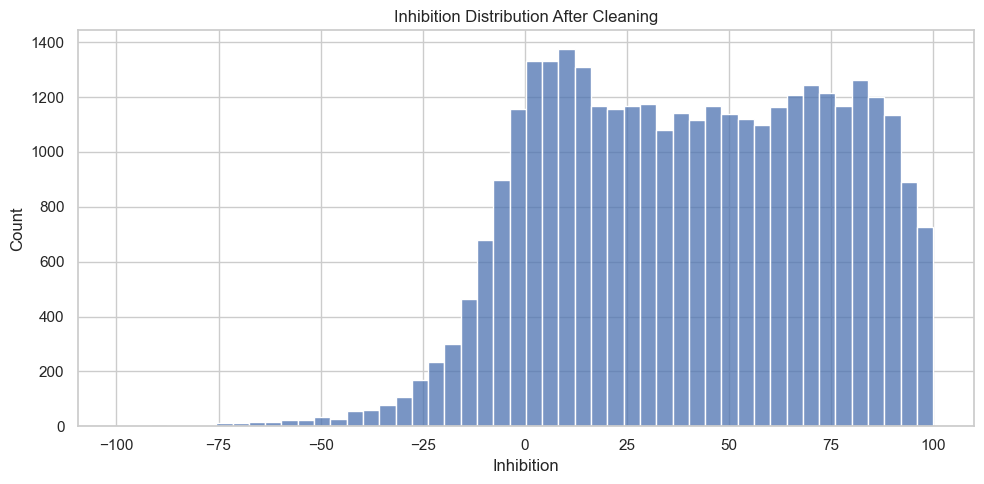

In [7]:
inhibition_stats = summarize_numeric(df_analysis["Inhibition"], "inhibition")
display(inhibition_stats)

plt.figure(figsize=(10, 5))
sns.histplot(pd.to_numeric(df_analysis["Inhibition"], errors="coerce").dropna(), bins=50)
plt.title("Inhibition Distribution After Cleaning")
plt.xlabel("Inhibition")
plt.tight_layout()
plt.show()

## 4. Sense And Antisense Lengths

In [8]:
length_summary = pd.DataFrame({
    "metric": [
        "Missing sense sequences",
        "Missing antisense sequences",
        "Inconsistent stored sense lengths",
        "Inconsistent stored antisense lengths",
    ],
    "count": [
        int(df_analysis["Sense_seqence"].isna().sum()),
        int(df_analysis["Antisense_seqence"].isna().sum()),
        int(df_analysis["sense_length_inconsistent"].sum()),
        int(df_analysis["antisense_length_inconsistent"].sum()),
    ],
})
display(length_summary)

display(summarize_numeric(df_analysis["length_sense_strand"], "stored_sense_length"))
display(summarize_numeric(df_analysis["sense_length_calculated"], "calculated_sense_length"))
display(summarize_numeric(df_analysis["length_anti_sense_strand"], "stored_antisense_length"))
display(summarize_numeric(df_analysis["antisense_length_calculated"], "calculated_antisense_length"))

,metric,count
0,Missing sense sequences,0
1,Missing antisense sequences,0
2,Inconsistent stored sense lengths,2208
3,Inconsistent stored antisense lengths,2905


,metric,value
0,stored_sense_length_min,17.000000
1,stored_sense_length_max,25.000000
2,stored_sense_length_avg,20.803146


,metric,value
0,calculated_sense_length_min,17.000000
1,calculated_sense_length_max,25.000000
2,calculated_sense_length_avg,20.637369


,metric,value
0,stored_antisense_length_min,15.000000
1,stored_antisense_length_max,25.000000
2,stored_antisense_length_avg,22.484001


,metric,value
0,calculated_antisense_length_min,13.000000
1,calculated_antisense_length_max,25.000000
2,calculated_antisense_length_avg,22.199492


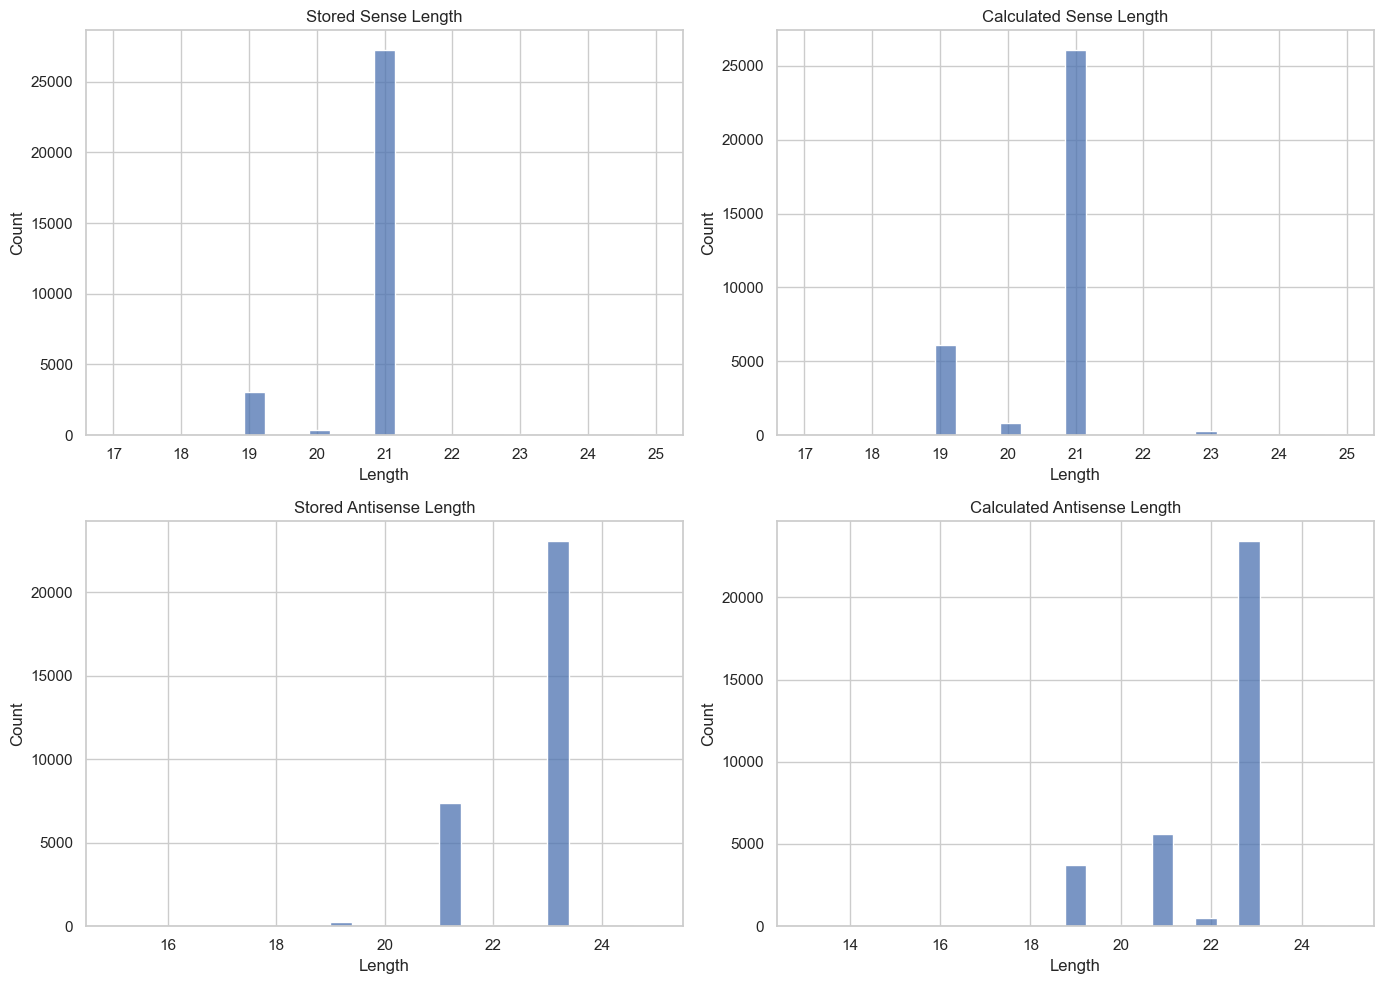

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(pd.to_numeric(df_analysis["length_sense_strand"], errors="coerce").dropna(), bins=25, ax=axes[0, 0])
axes[0, 0].set_title("Stored Sense Length")
axes[0, 0].set_xlabel("Length")

sns.histplot(df_analysis["sense_length_calculated"], bins=25, ax=axes[0, 1])
axes[0, 1].set_title("Calculated Sense Length")
axes[0, 1].set_xlabel("Length")

sns.histplot(pd.to_numeric(df_analysis["length_anti_sense_strand"], errors="coerce").dropna(), bins=25, ax=axes[1, 0])
axes[1, 0].set_title("Stored Antisense Length")
axes[1, 0].set_xlabel("Length")

sns.histplot(df_analysis["antisense_length_calculated"], bins=25, ax=axes[1, 1])
axes[1, 1].set_title("Calculated Antisense Length")
axes[1, 1].set_xlabel("Length")

plt.tight_layout()
plt.show()

In [10]:
invalid_sense_chars = invalid_characters(df_analysis["Sense_seqence"])
invalid_antisense_chars = invalid_characters(df_analysis["Antisense_seqence"])
invalid_sense_sequences = invalid_sequences(df_analysis["Sense_seqence"])
invalid_antisense_sequences = invalid_sequences(df_analysis["Antisense_seqence"])

print("Total invalid sense characters:", int(invalid_sense_chars["count"].sum()) if not invalid_sense_chars.empty else 0)
print("Total invalid antisense characters:", int(invalid_antisense_chars["count"].sum()) if not invalid_antisense_chars.empty else 0)
display(invalid_sense_chars)
display(invalid_antisense_chars)
display(invalid_sense_sequences)
display(invalid_antisense_sequences)

Total invalid sense characters: 8
Total invalid antisense characters: 18


,invalid_character,count
0,I,4
1,X,4


,invalid_character,count
0,d,18


,sequence,count
0,UGGCAGCUCCUUAUUGUIAUACG,2
1,CUCUAGACCXGUUUUGCUU,2
2,UUCUAGACCXGUUUUGCUA,2
3,CGUGAAUGGAGAGUICAGCCU,1
4,ACAUUUUGGUCICUAUACUAC,1


,sequence,count
0,ACAUUCUCGAAGUCGGUGACCdTdT,3
1,GCCUUUUUACAGCCAACUUdTdT,3
2,UGUGCUAGCAACACCCAAAdTdT,3


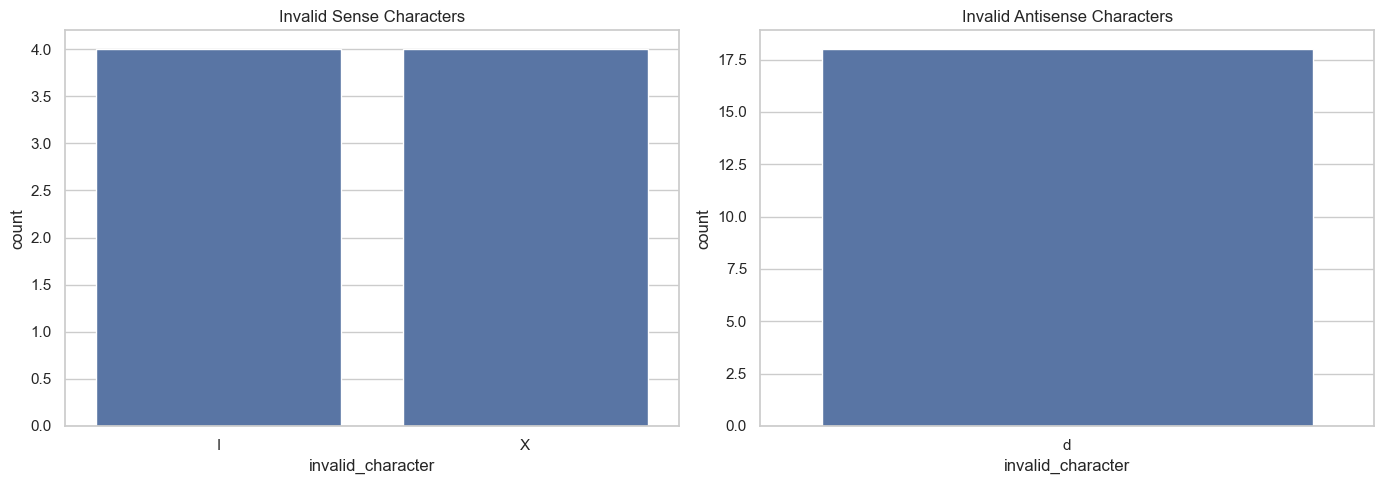

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if invalid_sense_chars.empty:
    axes[0].text(0.5, 0.5, "No invalid sense characters", ha="center", va="center")
    axes[0].set_axis_off()
else:
    sns.barplot(data=invalid_sense_chars, x="invalid_character", y="count", ax=axes[0])
    axes[0].set_title("Invalid Sense Characters")

if invalid_antisense_chars.empty:
    axes[1].text(0.5, 0.5, "No invalid antisense characters", ha="center", va="center")
    axes[1].set_axis_off()
else:
    sns.barplot(data=invalid_antisense_chars, x="invalid_character", y="count", ax=axes[1])
    axes[1].set_title("Invalid Antisense Characters")

plt.tight_layout()
plt.show()

## 5. Concentration Distribution

In [12]:
concentration_value_counts = df_analysis["Concentration"].value_counts(dropna=False).rename_axis("Concentration_nM").reset_index(name="count")
display(concentration_value_counts)


,Concentration_nM,count
0,10.00000,9617
1,0.10000,7956
2,1.00000,6091
3,50.00000,3568
4,100.00000,903
5,30.00000,783
6,0.50000,691
7,5.00000,527
8,20.00000,412
9,0.05000,307


### Rows With `0.041lnM`

In [13]:

concentration_0041lnm_rows = df_analysis.loc[
    df_analysis["Concentration"].astype(str).str.contains("0.041", na=False),
   ["ID", "Target_Gene", "Cell_Type", "Concentration", "Time_of_administration", "Sense_seqence", "Antisense_seqence"]
]


print("Rows with Original_Concentration == 0.041lnM:", len(concentration_0041lnm_rows))
display(concentration_0041lnm_rows[["ID", "Target_Gene", "Cell_Type", "Concentration", "Time_of_administration", "Sense_seqence", "Antisense_seqence"]].head(10))


Rows with Original_Concentration == 0.041lnM: 8


,ID,Target_Gene,Cell_Type,Concentration,Time_of_administration,Sense_seqence,Antisense_seqence
29734,036-09-03-09588-XX-24h-62.00,HSD17B13,Primary human hepatocytes,0.0411,24,CACCAAGGAUGAAGAGAUU,AAUCUCUUCAUCCUUGGUGCU
29735,036-09-03-09590-XX-24h-64.60,HSD17B13,Primary human hepatocytes,0.0411,24,CCAAGGAUGAAGAGAUUAU,AUAAUCUCUUCAUCCUUGGUG
29736,036-09-03-09593-XX-24h-59.40,HSD17B13,Primary human hepatocytes,0.0411,24,CAAAAAUCCAAGCACAAGA,UCUUGUGCUUGGAUUUUUGGU
29737,036-09-03-09602-XX-24h-45.00,HSD17B13,Primary human hepatocytes,0.0411,24,AAAUGAAAUGAAUAAAUAA,UUAUUUAUUCAUUUCAUUUUG
29914,037-09-03-09588-0.0411n-24h-62.00,HSD17B13,Primary human hepatocytes,0.0411,24,CACCAAGGAUGAAGAGAUU,AAUCUCUUCAUCCUUGGUGCU
29915,037-09-03-09590-0.0411n-24h-64.60,HSD17B13,Primary human hepatocytes,0.0411,24,CCAAGGAUGAAGAGAUUAU,AUAAUCUCUUCAUCCUUGGUG
29916,037-09-03-09593-0.0411n-24h-59.40,HSD17B13,Primary human hepatocytes,0.0411,24,CAAAAAUCCAAGCACAAGA,UCUUGUGCUUGGAUUUUUGGU
29917,037-09-03-09602-0.0411n-24h-45.00,HSD17B13,Primary human hepatocytes,0.0411,24,AAAUGAAAUGAAUAAAUAA,UUAUUUAUUCAUUUCAUUUUG


,metric,value
0,concentration_nM_min,0.000170
1,concentration_nM_max,200.000000
2,concentration_nM_avg,13.620258


Rows with concentration over 100 nM: 219 (0.65%)


,metric,value
0,concentration_over_100_nM_count,219.00
1,concentration_over_100_nM_percent,0.65


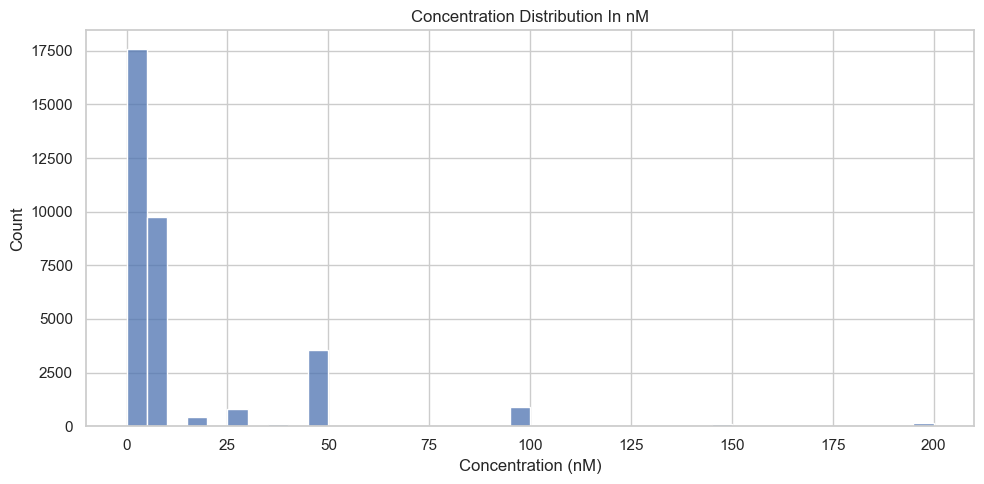

In [14]:



concentration_stats_nm = summarize_numeric(df_analysis["Concentration"], "concentration_nM")
display(concentration_stats_nm)

over_100nm_count = int((df_analysis["Concentration"] > 100).sum())
over_100nm_percent = round((df_analysis["Concentration"] > 100).mean() * 100, 2)
print(f"Rows with concentration over 100 nM: {over_100nm_count} ({over_100nm_percent}%)")
display(pd.DataFrame({
    "metric": ["concentration_over_100_nM_count", "concentration_over_100_nM_percent"],
    "value": [over_100nm_count, over_100nm_percent],
} ))



plt.figure(figsize=(10, 5))
sns.histplot(df_analysis["Concentration"], bins=40)
plt.title("Concentration Distribution In nM")
plt.xlabel("Concentration (nM)")
plt.tight_layout()
plt.show()

## 6. Time Distribution

,Time_of_administration,count
0,24,25153
1,48,6415
2,72,1369
3,168,314
4,40,199


,metric,value
0,time_of_administration_min,24.000000
1,time_of_administration_max,168.000000
2,time_of_administration_avg,32.014111


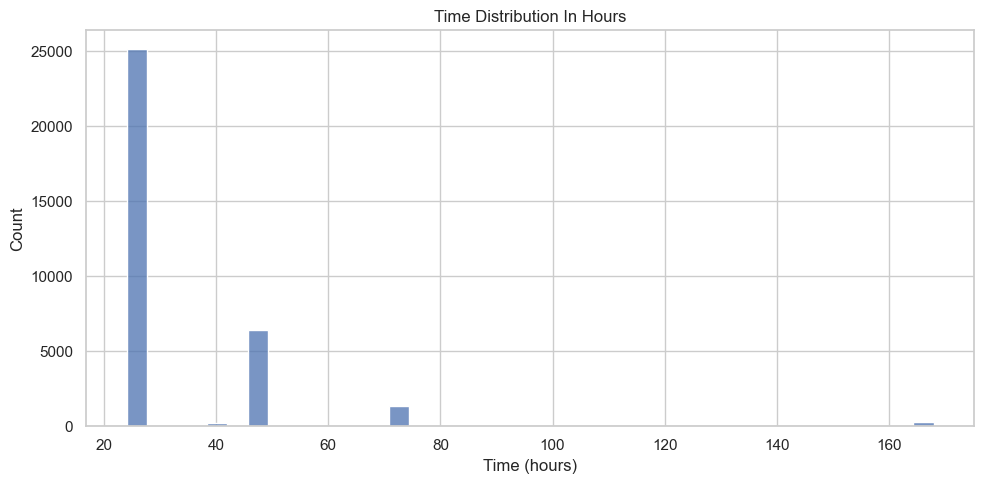

In [15]:
time_value_counts = df_analysis["Time_of_administration"].value_counts(dropna=False).reset_index(name="count")

display(time_value_counts)

time_stats = summarize_numeric(df_analysis["Time_of_administration"], "time_of_administration")
display(time_stats)

plt.figure(figsize=(10, 5))
sns.histplot(df_analysis["Time_of_administration"].dropna(), bins=40)
plt.title("Time Distribution In Hours")
plt.xlabel("Time (hours)")
plt.tight_layout()
plt.show()


In [16]:
time_stats_by_value = (
    df_analysis["Time_of_administration"]
    .value_counts(dropna=False)
    .rename_axis("Time_of_administration")
    .reset_index(name="count")
    .sort_values("Time_of_administration", na_position="last")
)
display(time_stats_by_value)


,Time_of_administration,count
0,24,25153
4,40,199
1,48,6415
2,72,1369
3,168,314


## 7. Time And Concentration Relationship

,ID,Time_of_administration,Concentration
0,001-01-01-00001-100n-48h-88.00,48,100.0
1,001-01-01-00002-100n-48h-90.00,48,100.0
2,001-01-01-00003-100n-48h-90.00,48,100.0
3,001-01-01-00004-100n-48h-89.00,48,100.0
4,001-01-01-00005-100n-48h-87.00,48,100.0
5,001-01-01-00006-100n-48h-91.00,48,100.0
6,001-01-01-00007-100n-48h-62.00,48,100.0
7,002-01-02-00008-10n-24h-93.62,24,10.0
8,002-01-02-00009-10n-24h-92.55,24,10.0
9,002-01-02-00010-10n-24h-93.48,24,10.0


Rows with both time and concentration: 33450


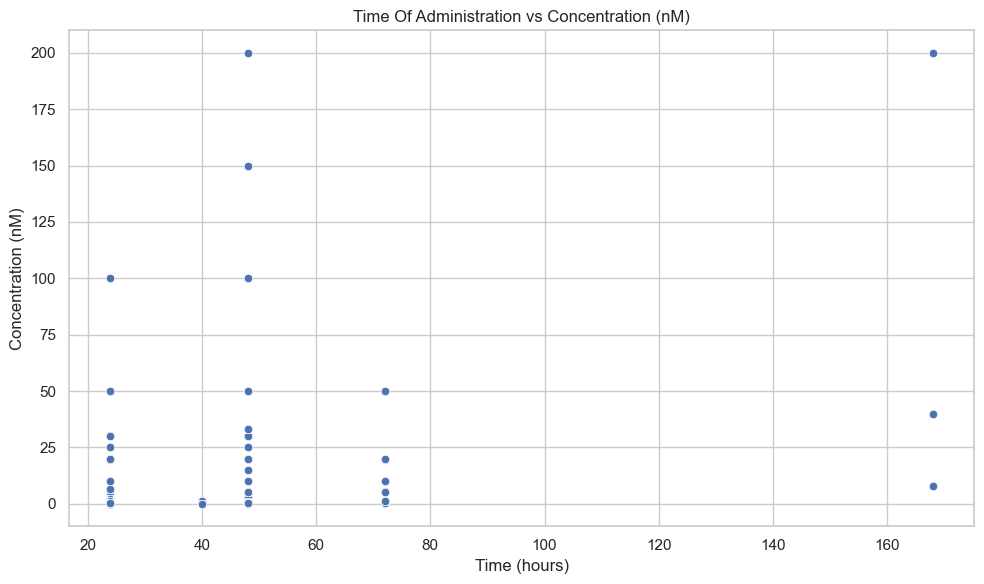

In [17]:
time_concentration_df = df_analysis[["ID", "Time_of_administration", "Concentration"]].copy()
display(time_concentration_df.head(25))

plot_df = time_concentration_df.dropna(subset=["Time_of_administration", "Concentration"]).copy()
print("Rows with both time and concentration:", len(plot_df))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="Time_of_administration", y="Concentration")
plt.title("Time Of Administration vs Concentration (nM)")
plt.xlabel("Time (hours)")
plt.ylabel("Concentration (nM)")
plt.tight_layout()
plt.show()


In [18]:
missing_time_concentration = time_concentration_df.loc[time_concentration_df["Time_of_administration"].isna()].copy()
print("Rows with NaN time:", len(missing_time_concentration))
display(missing_time_concentration)

missing_time_concentration_summary = missing_time_concentration["Concentration"].value_counts(dropna=False).rename_axis("Concentration").reset_index(name="count")
display(missing_time_concentration_summary)

if missing_time_concentration["Concentration"].notna().any():
    plt.figure(figsize=(10, 5))
    sns.histplot(missing_time_concentration["Concentration"].dropna(), bins=30)
    plt.title("Concentration (nM) For Rows With NaN Time")
    plt.xlabel("Concentration (nM)")
    plt.tight_layout()
    plt.show()


Rows with NaN time: 0


,ID,Time_of_administration,Concentration


,Concentration,count


## 8. Cell Type Counts

,Cell_Type,count
0,Hep3B,12165
1,Primary Cynomolgus Monkey Hepatocytes,4445
2,COS7,3888
3,Primary human hepatocytes,3015
4,Hela,2005
5,Be(2)C cell line,1966
6,HepG2,1651
7,Huh7,1602
8,HEK293A,1048
9,Primary mouse hepatocytes,501


<Figure size 1200x800 with 0 Axes>

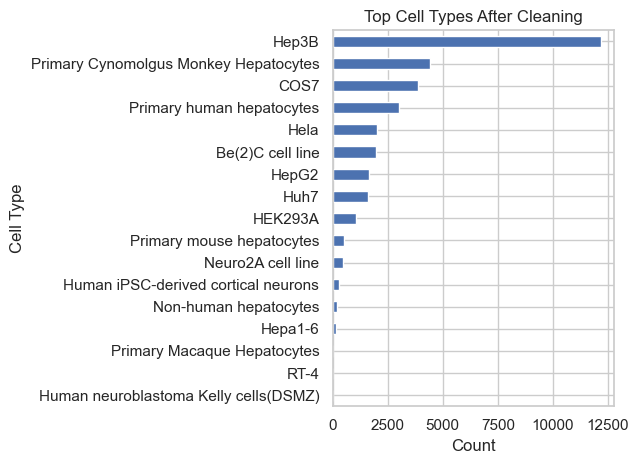

In [19]:
cell_type_counts = df_analysis["Cell_Type"].fillna("Missing").value_counts(dropna=False).rename_axis("Cell_Type").reset_index(name="count")
display(cell_type_counts)

plt.figure(figsize=(12, 8))
cell_type_counts.head(30).sort_values("count").plot(kind="barh", x="Cell_Type", y="count", legend=False)
plt.title("Top Cell Types After Cleaning")
plt.xlabel("Count")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()


## 9. Cell Line And Time Relationship

In [20]:
cell_time_df = df_analysis[["ID", "Cell_Type", "Time_of_administration"]].copy()
display(cell_time_df.head(25))

cell_time_summary = cell_time_df.groupby("Cell_Type")["Time_of_administration"].agg(["count", "min", "max", "mean"]).reset_index()
cell_time_summary = cell_time_summary.sort_values(["count", "mean"], ascending=[False, True])
display(cell_time_summary)

cell_counts = cell_time_df.groupby("Cell_Type").size().reset_index(name="total_rows")
missing_time_by_cell = cell_time_df.groupby("Cell_Type")["Time_of_administration"].apply(lambda series: int(series.isna().sum())).reset_index(name="missing_time_count")
missing_time_by_cell = missing_time_by_cell.merge(cell_counts, on="Cell_Type", how="left")
missing_time_by_cell["missing_time_percent"] = ((missing_time_by_cell["missing_time_count"] / missing_time_by_cell["total_rows"]) * 100).round(2)
display(missing_time_by_cell.sort_values(["missing_time_count", "missing_time_percent"], ascending=[False, False]))


,ID,Cell_Type,Time_of_administration
0,001-01-01-00001-100n-48h-88.00,Hela,48
1,001-01-01-00002-100n-48h-90.00,Hela,48
2,001-01-01-00003-100n-48h-90.00,Hela,48
3,001-01-01-00004-100n-48h-89.00,Hela,48
4,001-01-01-00005-100n-48h-87.00,Hela,48
5,001-01-01-00006-100n-48h-91.00,Hela,48
6,001-01-01-00007-100n-48h-62.00,Hela,48
7,002-01-02-00008-10n-24h-93.62,Hep3B,24
8,002-01-02-00009-10n-24h-92.55,Hep3B,24
9,002-01-02-00010-10n-24h-93.48,Hep3B,24


,Cell_Type,count,min,max,mean
4,Hep3B,12165,24,48,24.353802
12,Primary Cynomolgus Monkey Hepatocytes,4445,24,48,32.023397
1,COS7,3888,24,72,49.802469
14,Primary human hepatocytes,3015,24,48,40.668657
3,Hela,2005,24,48,26.182544
0,Be(2)C cell line,1966,24,24,24.000000
5,HepG2,1651,24,48,25.744397
7,Huh7,1602,24,48,35.895131
2,HEK293A,1048,24,72,24.549618
15,Primary mouse hepatocytes,501,24,24,24.000000


,Cell_Type,missing_time_count,total_rows,missing_time_percent
0,Be(2)C cell line,0,1966,0.0
1,COS7,0,3888,0.0
2,HEK293A,0,1048,0.0
3,Hela,0,2005,0.0
4,Hep3B,0,12165,0.0
5,HepG2,0,1651,0.0
6,Hepa1-6,0,139,0.0
7,Huh7,0,1602,0.0
8,Human iPSC-derived cortical neurons,0,314,0.0
9,Human neuroblastoma Kelly cells(DSMZ),0,10,0.0


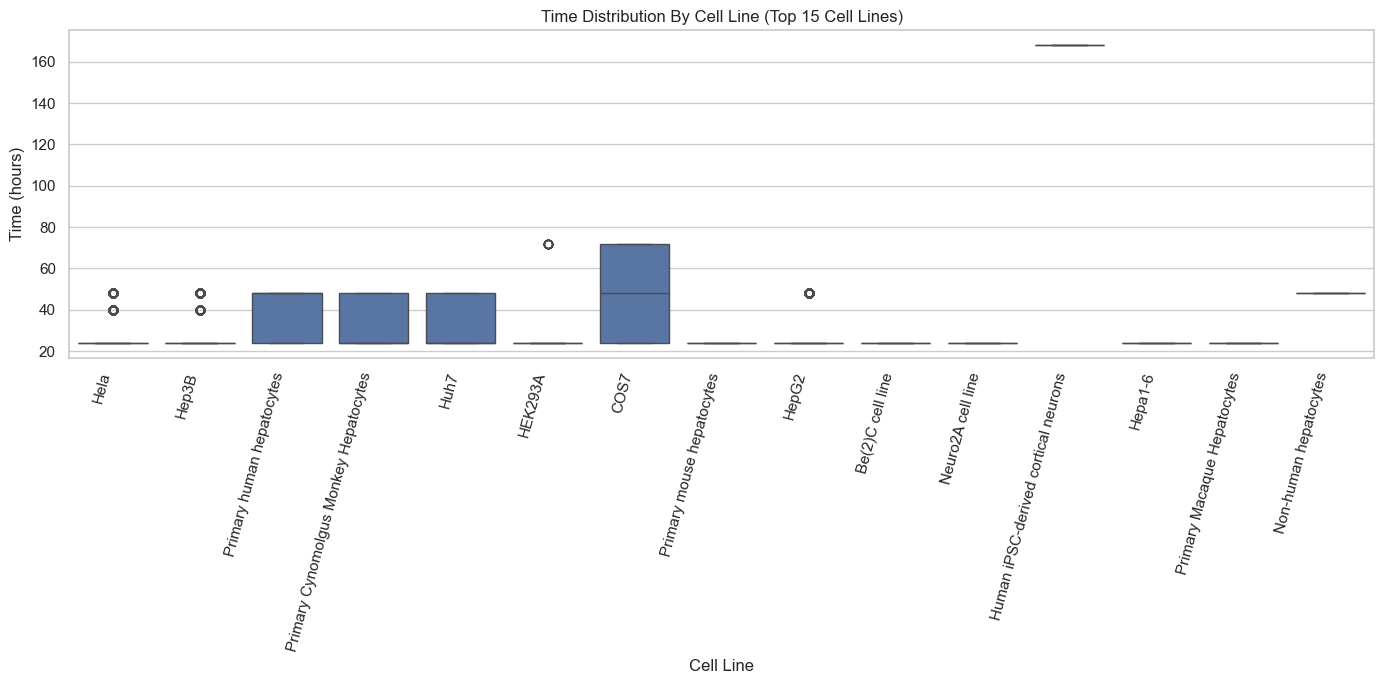

,ID,Cell_Type,Time_of_administration


In [21]:
top_cell_lines = cell_time_df["Cell_Type"].value_counts().head(15).index
plot_cell_time_df = cell_time_df[cell_time_df["Cell_Type"].isin(top_cell_lines)].copy()

plt.figure(figsize=(14, 7))
sns.boxplot(data=plot_cell_time_df, x="Cell_Type", y="Time_of_administration")
plt.title("Time Distribution By Cell Line (Top 15 Cell Lines)")
plt.xlabel("Cell Line")
plt.ylabel("Time (hours)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

missing_time_cell_rows = cell_time_df.loc[cell_time_df["Time_of_administration"].isna()].copy()
display(missing_time_cell_rows.head(25))


## 10. Cell Line, Concentration, And Time Patterns

In [22]:
cell_conc_time_df = df_analysis[["ID", "Cell_Type", "Concentration", "Time_of_administration"]].copy()

cell_conc_time_patterns = (
    cell_conc_time_df.dropna(subset=["Concentration", "Time_of_administration"])
    .groupby(["Cell_Type", "Concentration", "Time_of_administration"])
    .size()
    .reset_index(name="row_count")
    .sort_values(["Cell_Type", "Concentration", "row_count", "Time_of_administration"], ascending=[True, True, False, True])
)
display(cell_conc_time_patterns.head(100))

observed_time_options = (
    cell_conc_time_df.dropna(subset=["Concentration", "Time_of_administration"])
    .groupby(["Cell_Type", "Concentration"])["Time_of_administration"]
    .agg(
        observed_row_count="count",
        unique_time_count="nunique",
        observed_times=lambda series: sorted(series.unique()),
        modal_time_of_administration=lambda series: series.value_counts().index[0],
        modal_time_support=lambda series: int(series.value_counts().iloc[0]),
    )
    .reset_index()
)
observed_time_options["observed_times"] = observed_time_options["observed_times"].apply(lambda values: ", ".join(f"{value:g} h" for value in values))
display(observed_time_options.head(100))


,Cell_Type,Concentration,Time_of_administration,row_count
0,Be(2)C cell line,0.10000,24,749
1,Be(2)C cell line,1.00000,24,456
2,Be(2)C cell line,10.00000,24,761
4,COS7,0.10000,48,595
3,COS7,0.10000,24,300
5,COS7,0.50000,72,448
6,COS7,1.00000,24,231
7,COS7,5.00000,72,449
9,COS7,10.00000,48,595
8,COS7,10.00000,24,300


,Cell_Type,Concentration,observed_row_count,unique_time_count,observed_times,modal_time_of_administration,modal_time_support
0,Be(2)C cell line,0.10000,749,1,24 h,24,749
1,Be(2)C cell line,1.00000,456,1,24 h,24,456
2,Be(2)C cell line,10.00000,761,1,24 h,24,761
3,COS7,0.10000,895,2,"24 h, 48 h",48,595
4,COS7,0.50000,448,1,72 h,72,448
5,COS7,1.00000,231,1,24 h,24,231
6,COS7,5.00000,449,1,72 h,72,449
7,COS7,10.00000,895,2,"24 h, 48 h",48,595
8,COS7,50.00000,970,3,"24 h, 48 h, 72 h",72,450
9,HEK293A,0.00030,40,1,24 h,24,40


In [23]:
missing_time_inference = cell_conc_time_df.loc[cell_conc_time_df["Time_of_administration"].isna()].copy()
missing_time_inference = missing_time_inference.merge(
    observed_time_options,
    on=["Cell_Type", "Concentration"],
    how="left",
)
display(missing_time_inference.head(100))

missing_time_inference_summary = (
    missing_time_inference.groupby(["Cell_Type", "Concentration", "observed_times", "modal_time_of_administration", "modal_time_support", "observed_row_count", "unique_time_count"], dropna=False)
    .size()
    .reset_index(name="missing_row_count")
    .sort_values(["missing_row_count", "Cell_Type", "Concentration"], ascending=[False, True, True])
)
display(missing_time_inference_summary.head(100))


,ID,Cell_Type,Concentration,Time_of_administration,observed_row_count,unique_time_count,observed_times,modal_time_of_administration,modal_time_support


,Cell_Type,Concentration,observed_times,modal_time_of_administration,modal_time_support,observed_row_count,unique_time_count,missing_row_count


## 10. Target Genes

,Target_Gene,count
0,PNPLA3,8591
1,HSD17B13,6189
2,AGT,4778
3,INHBE,3509
4,PCSK9,2831
5,APP,2350
6,LPA,1479
7,MAPT,1317
8,CTNNB1,1285
9,ANGPTL3,495


<Figure size 1200x800 with 0 Axes>

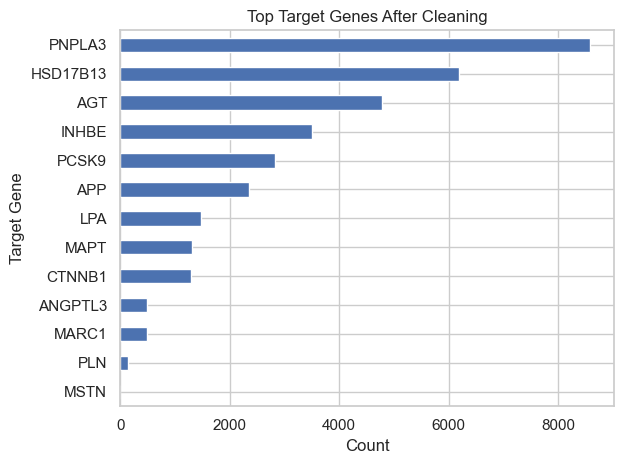

In [24]:
target_gene_counts = df_analysis["Target_Gene"].fillna("Missing").value_counts().rename_axis("Target_Gene").reset_index(name="count")
display(target_gene_counts)

plt.figure(figsize=(12, 8))
target_gene_counts.head(30).sort_values("count").plot(kind="barh", x="Target_Gene", y="count", legend=False)
plt.title("Top Target Genes After Cleaning")
plt.xlabel("Count")
plt.ylabel("Target Gene")
plt.tight_layout()
plt.show()

## Save Outputs

In [26]:
processed_dir.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(processed_dir / "CMsiRNA_after_cleaning_dataset.tsv", sep="\t", index=False)
df_analysis.to_csv(processed_dir / "CMsiRNA_after_cleaning_analysis_dataset.tsv", sep="\t", index=False)
missing_summary.to_csv(processed_dir / "CMsiRNA_after_cleaning_missingness.csv")
duplicate_summary.to_csv(processed_dir / "CMsiRNA_after_cleaning_duplicates.csv", index=False)
target_gene_counts.to_csv(processed_dir / "CMsiRNA_after_cleaning_target_genes.csv", index=False)


print("Saved outputs to:", processed_dir)

Saved outputs to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed
